# Simple Re-ranking Notebook

This notebook copies the basic setup from retrieval_query_strategy_2_helper_func.ipynb and adds a minimal re-ranking step.

Flow:
1. Build query text (variant 1 style).
2. Retrieve top-N candidates from Qdrant.
3. Compare baseline top-K vs re-ranked top-K.
4. Show PR-level and category-level results.

In [ ]:
import ast
import json
import random
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer

RANDOM_SEED = 42
SAMPLE_SIZE = 50
TOP_K_FINAL = 7
TOP_N_CANDIDATES = 25
COLLECTION_NAME = "guideline_embeddings"
MODEL_NAME = "BAAI/bge-large-en-v1.5"

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EVAL_PATH = DATA_DIR / "evaluation.json"

GROUPED_VIOLATION_CATEGORIES = [
    "naming_convention",
    "unused_import",
    "indentation",
    "mutable_default",
    "documentation_formatting",
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation file: {EVAL_PATH}")

c:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project
Evaluation file: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation.json


In [8]:
import importlib
import sys

sys.path.insert(0, str(PROJECT_ROOT / "src"))
qs = importlib.import_module("rag_model.query_strategy")
qs = importlib.reload(qs)

# Use the refined regex variant when available; fallback to v1.
query_builder = getattr(qs, "query_strategy_regex_intelligent_v2", qs.query_strategy_regex_intelligent)
retrieve_guidelines = qs.retrieve_guidelines

print("Loaded query_strategy module.")
print(f"Active query builder: {query_builder.__name__}")

Loaded query_strategy module.
Active query builder: query_strategy_regex_intelligent_v2


In [3]:
with EVAL_PATH.open("r", encoding="utf-8") as f:
    evaluation_data = json.load(f)

random.seed(RANDOM_SEED)
sampled_entries = random.sample(evaluation_data, k=min(SAMPLE_SIZE, len(evaluation_data)))
gt_map = {e.get("id"): e.get("ground_truth_reviews") for e in evaluation_data}

client = QdrantClient(url="http://localhost:6333")
model = SentenceTransformer(MODEL_NAME)

print(f"Sampled entries: {len(sampled_entries)}")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1749.07it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sampled entries: 33


In [9]:
# Simple reranking settings (tune these first)
LEXICAL_WEIGHT = 0.35
CATEGORY_BONUS = 0.15
RANK_PENALTY = 0.01
MAX_PER_CATEGORY = 2

pr_rows = []

for entry in sampled_entries:
    query_text = query_builder(entry)
    points = retrieve_guidelines(
        query_text=query_text,
        repo_name=entry.get("repo"),
        top_k=TOP_N_CANDIDATES,
        client=client,
        embed_model=model,
        collection_name=COLLECTION_NAME,
    )

    candidate_rows = []
    query_tokens = set(str(query_text).lower().replace("_", " ").split())

    for rank_idx, point in enumerate(points):
        payload = getattr(point, "payload", None)
        obj = payload if isinstance(payload, dict) else None
        if obj is None and isinstance(payload, str):
            try:
                maybe = ast.literal_eval(payload)
                if isinstance(maybe, dict):
                    obj = maybe
            except Exception:
                obj = None

        category = None
        text_val = ""
        if isinstance(obj, dict):
            for key in ["violation_category", "category", "label", "violation"]:
                val = obj.get(key)
                if isinstance(val, str) and val.strip():
                    category = val.strip().lower().replace("-", "_").replace(" ", "_")
                    break
            for key in ["text", "content", "chunk", "guideline"]:
                val = obj.get(key)
                if isinstance(val, str) and val.strip():
                    text_val = val
                    break

        if not text_val and isinstance(payload, str):
            text_val = payload

        sem_score = float(getattr(point, "score", 0.0) or 0.0)
        chunk_tokens = set(str(text_val).lower().replace("_", " ").split())
        lexical_overlap = len(query_tokens & chunk_tokens) / max(1, len(query_tokens))
        cat_bonus = CATEGORY_BONUS if (category and category in query_text.lower()) else 0.0
        rerank_score = sem_score + (LEXICAL_WEIGHT * lexical_overlap) + cat_bonus - (RANK_PENALTY * rank_idx)

        candidate_rows.append({
            "rank_idx": rank_idx,
            "category": category,
            "sem_score": sem_score,
            "lexical_overlap": lexical_overlap,
            "rerank_score": rerank_score,
        })

    cand_df = pd.DataFrame(candidate_rows)

    # Baseline: original retrieval order
    baseline_categories = [
        c for c in cand_df.sort_values("rank_idx")["category"].tolist()[:TOP_K_FINAL] if c
    ]

    # Reranked with a simple per-category cap to reduce repeated false positives
    reranked_categories = []
    cat_counts = {}
    for c in cand_df.sort_values("rerank_score", ascending=False)["category"].tolist():
        if not c:
            continue
        prev = cat_counts.get(c, 0)
        if prev >= MAX_PER_CATEGORY:
            continue
        reranked_categories.append(c)
        cat_counts[c] = prev + 1
        if len(reranked_categories) >= TOP_K_FINAL:
            break

    gt_categories = []
    for gt in (gt_map.get(entry.get("id")) or []):
        cat = gt.get("violation_category") if isinstance(gt, dict) else gt
        if isinstance(cat, str):
            cat_norm = cat.strip().lower().replace("-", "_").replace(" ", "_")
            if cat_norm in GROUPED_VIOLATION_CATEGORIES:
                gt_categories.append(cat_norm)

    pr_rows.append({
        "id": entry.get("id"),
        "repo": entry.get("repo"),
        "query_text": query_text,
        "gt_categories": sorted(set(gt_categories)),
        "baseline_categories": baseline_categories,
        "reranked_categories": reranked_categories,
    })

pr_df = pd.DataFrame(pr_rows)
display(pr_df[["id", "repo", "gt_categories", "baseline_categories", "reranked_categories"]].head(10))

,id,repo,gt_categories,baseline_categories,reranked_categories
0,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,"[mutable_default, naming_convention, unused_im...","[naming_convention, documentation_formatting, ...","[naming_convention, documentation_formatting, ..."
1,synthetic-django_PR_36,kannan-dedsec/synthetic-django,[naming_convention],"[indentation, unused_import, naming_convention...","[indentation, indentation, unused_import, nami..."
2,synthetic-django_PR_24,kannan-dedsec/synthetic-django,"[mutable_default, naming_convention]","[indentation, unused_import, naming_convention...","[indentation, indentation, unused_import, nami..."
3,synthetic-fastapi_PR_38,kannan-dedsec/synthetic-fastapi,[unused_import],"[naming_convention, indentation, naming_conven...","[naming_convention, naming_convention, indenta..."
4,synthetic-fastapi_PR_34,kannan-dedsec/synthetic-fastapi,[naming_convention],"[naming_convention, indentation, naming_conven...","[naming_convention, naming_convention, indenta..."
5,synthetic-fastapi_PR_31,kannan-dedsec/synthetic-fastapi,[unused_import],"[naming_convention, indentation, naming_conven...","[naming_convention, naming_convention, indenta..."
6,synthetic-django_PR_39,kannan-dedsec/synthetic-django,"[documentation_formatting, indentation, naming...","[indentation, unused_import, naming_convention...","[indentation, indentation, unused_import, nami..."
7,synthetic-django_PR_35,kannan-dedsec/synthetic-django,"[documentation_formatting, unused_import]","[indentation, unused_import, naming_convention...","[indentation, indentation, unused_import, nami..."
8,synthetic-sklearn_PR_30,kannan-dedsec/synthetic-sklearn,"[mutable_default, naming_convention]","[naming_convention, documentation_formatting, ...","[naming_convention, documentation_formatting, ..."
9,synthetic-pandas_PR_32,kannan-dedsec/synthetic-pandas,[naming_convention],"[indentation, documentation_formatting, indent...","[indentation, documentation_formatting, indent..."


In [10]:
k_values = [1, 3, 5, 7]
records = []
category_records = []

for mode in ["baseline", "reranked"]:
    col_name = "baseline_categories" if mode == "baseline" else "reranked_categories"

    for k in k_values:
        for _, row in pr_df.iterrows():
            gt_set = set(row["gt_categories"] or [])
            topk = [c for c in (row[col_name] or [])[:k] if c]

            if len(gt_set) == 0:
                continue

            matched = {c for c in gt_set if c in topk}
            recall = len(matched) / min(5, len(gt_set))
            precision = (sum(1 for c in topk if c in gt_set) / len(topk)) if topk else 0.0

            rr_vals = []
            for g in gt_set:
                rr = 0.0
                for rank, c in enumerate(topk, start=1):
                    if c == g:
                        rr = 1.0 / rank
                        break
                rr_vals.append(rr)
            mrr = sum(rr_vals) / len(rr_vals) if rr_vals else 0.0

            records.append({
                "mode": mode,
                "k": k,
                "id": row["id"],
                "recall_at_k": recall,
                "precision_at_k": precision,
                "mrr_at_k": mrr,
            })

        for cat in GROUPED_VIOLATION_CATEGORIES:
            gt_count = 0
            ret_count = 0
            tp = 0
            for _, row in pr_df.iterrows():
                gt_set = set(row["gt_categories"] or [])
                topk = [c for c in (row[col_name] or [])[:k] if c]
                if cat in gt_set:
                    gt_count += 1
                if cat in topk:
                    ret_count += 1
                if cat in gt_set and cat in topk:
                    tp += 1

            fp = ret_count - tp
            category_records.append({
                "mode": mode,
                "k": k,
                "category": cat,
                "gt_count": gt_count,
                "retrieved_count": ret_count,
                "tp": tp,
                "fp": fp,
                "recall": (tp / gt_count) if gt_count else 0.0,
                "precision": (tp / ret_count) if ret_count else 0.0,
            })

metrics_long_df = pd.DataFrame(records)
overall_df = metrics_long_df.groupby(["mode", "k"], as_index=False)[["recall_at_k", "precision_at_k", "mrr_at_k"]].mean()
category_df = pd.DataFrame(category_records)

print("Overall metrics (baseline vs reranked):")
display(overall_df)
print("Category-level stats:")
display(category_df.head(30))

Overall metrics (baseline vs reranked):


,mode,k,recall_at_k,precision_at_k,mrr_at_k
0,baseline,1,0.214646,0.363636,0.214646
1,baseline,3,0.376263,0.313131,0.286616
2,baseline,5,0.540404,0.296970,0.322854
3,baseline,7,0.560606,0.259740,0.325740
4,reranked,1,0.214646,0.363636,0.214646
5,reranked,3,0.358586,0.313131,0.265152
6,reranked,5,0.676768,0.303030,0.335732
7,reranked,7,0.848485,0.346320,0.360263


Category-level stats:


,mode,k,category,gt_count,retrieved_count,tp,fp,recall,precision
0,baseline,1,naming_convention,17,16,7,9,0.411765,0.437500
1,baseline,1,unused_import,21,0,0,0,0.000000,0.000000
2,baseline,1,indentation,5,17,5,12,1.000000,0.294118
3,baseline,1,mutable_default,10,0,0,0,0.000000,0.000000
4,baseline,1,documentation_formatting,5,0,0,0,0.000000,0.000000
5,baseline,3,naming_convention,17,23,10,13,0.588235,0.434783
6,baseline,3,unused_import,21,7,5,2,0.238095,0.714286
7,baseline,3,indentation,5,24,5,19,1.000000,0.208333
8,baseline,3,mutable_default,10,0,0,0,0.000000,0.000000
9,baseline,3,documentation_formatting,5,15,1,14,0.200000,0.066667


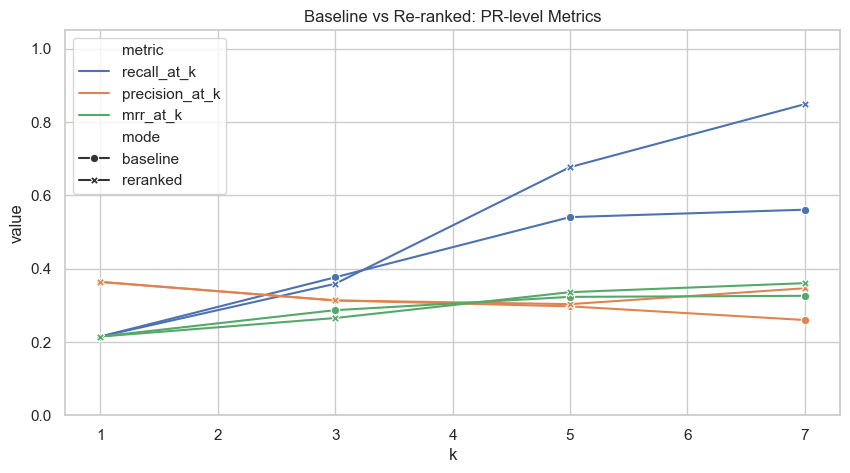

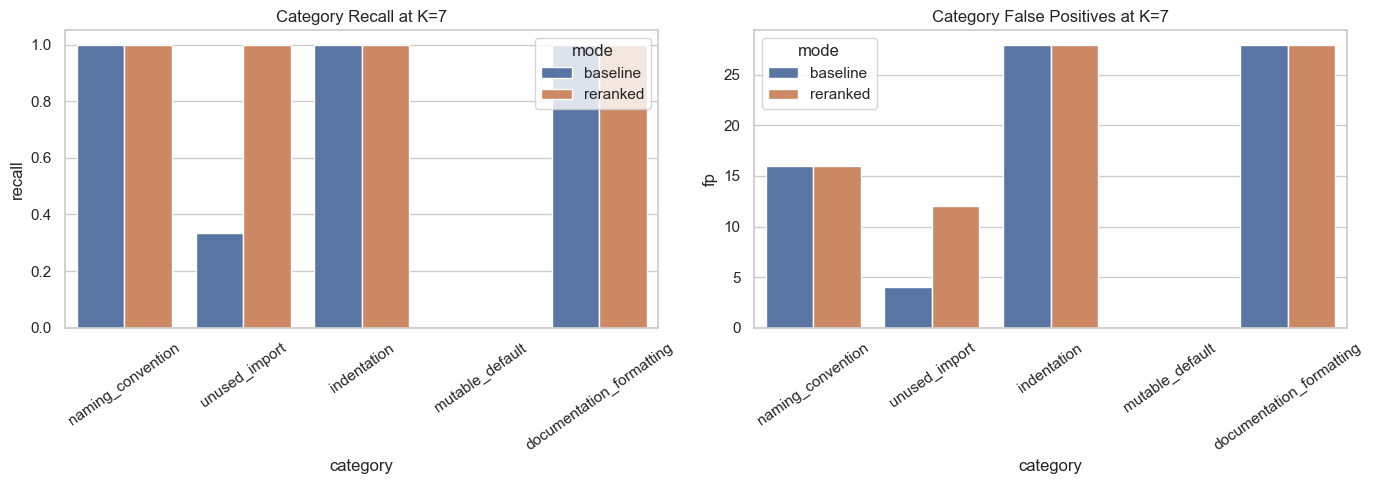

In [11]:
sns.set_theme(style="whitegrid")

plot_df = overall_df.melt(
    id_vars=["mode", "k"],
    value_vars=["recall_at_k", "precision_at_k", "mrr_at_k"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="k", y="value", hue="metric", style="mode", markers=True, dashes=False)
plt.ylim(0, 1.05)
plt.title("Baseline vs Re-ranked: PR-level Metrics")
plt.show()

k_show = 7
cat_plot = category_df[category_df["k"] == k_show].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=cat_plot, x="category", y="recall", hue="mode", ax=axes[0])
axes[0].set_title(f"Category Recall at K={k_show}")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=cat_plot, x="category", y="fp", hue="mode", ax=axes[1])
axes[1].set_title(f"Category False Positives at K={k_show}")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [12]:
out_dir = PROJECT_ROOT / "notebooks" / f"rerank_simple_outputs_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
out_dir.mkdir(parents=True, exist_ok=True)

pr_df.to_csv(out_dir / "pr_rows.csv", index=False)
overall_df.to_csv(out_dir / "overall_metrics.csv", index=False)
category_df.to_csv(out_dir / "category_metrics.csv", index=False)

for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(out_dir / f"figure_{fig_num}.png", dpi=200, bbox_inches="tight")

print(f"Saved outputs to: {out_dir}")

Saved outputs to: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\rerank_simple_outputs_20260404_150553
